<a href="https://colab.research.google.com/github/amigli/Q-Bert_RL/blob/main/Notebook/DQN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Training e Test con DQN
In questo notebook è presente il training di Q*Bert sfruttando l'algoritmo DQN

## Download Repository

Download della repository per utilizzare le classi create su Google Colab

In [1]:
from google.colab import userdata

In [2]:
! git clone https://{userdata.get('TokenGithub')}"@github.com/amigli/Q-Bert_RL.git"

Cloning into 'Q-Bert_RL'...
remote: Enumerating objects: 553, done.
remote: Counting objects: 100% (27/27), done.
remote: Compressing objects: 100% (13/13), done.
remote: Total 553 (delta 16), reused 20 (delta 14), pack-reused 526 (from 1)
Receiving objects: 100% (553/553), 6.47 MiB | 20.26 MiB/s, done.
Resolving deltas: 100% (352/352), done.


In [3]:
%cd Q-Bert_RL

/content/Q-Bert_RL


## Installazione dei requirements

Vengono installati tutti i moduli necessari dal file requirements.txt

In [4]:
!pip install gymnasium

In [5]:
!pip install ale-py

In [6]:
!pip install moviepy

## Salvataggio statistiche
Predisposizione delle cartelle su Drive per il salvataggio delle statistiche di training

In [7]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [11]:
dir = '/content/drive/MyDrive/Q-Bert_RL/DQN/'

In [12]:
import os

if not(os.path.exists(dir)):
  os.mkdir(dir)

In [13]:
import datetime
dir = dir + "Training_" + str(datetime.datetime.now())

if not(os.path.exists(dir)):
  os.mkdir(dir)

In [14]:
dir_models = dir + "/models/"

if not(os.path.exists(dir_models)):
  os.mkdir(dir_models)

## Training

In [16]:
import gymnasium as gym
import ale_py
from tqdm.notebook import tqdm, trange
from gymnasium.wrappers import RecordEpisodeStatistics, RecordVideo
from EnvironmentWrappers.ObsRewardWrapper import ObsRewardWrapper
from Algorithms.QBertAgent_DQN import DQNAgent
from EnvironmentWrappers.utils import salva_csv

In [17]:
class OurRewardWrapper(gym.RewardWrapper):
  def reward(self, reward):
    if reward < 0:
      return -1

    if reward > 0:
      return 1

    return 0

In [19]:
gym.register_envs(ale_py)

learning_rate = 0.001
n_episodes = 10000
start_epsilon = 1.0
epsilon_decay = start_epsilon / (n_episodes / 2)
final_epsilon = 0.1

env = gym.make("ALE/Qbert-ram-v5")
env =  ObsRewardWrapper(env)
env = OurRewardWrapper(env)
env = RecordEpisodeStatistics(env, buffer_length=n_episodes)
obs, info = env.reset()

reward_per_episode = []
step_per_episode = []
epsilon_value = []

state_dim = obs.shape[0]
action_dim = env.action_space.n
agent = DQNAgent(state_dim, action_dim, lr=0.0001, gamma=0.99, epsilon=1.0, epsilon_decay=0.995, buffer_size=10000)

last_reward = 0
# TRAINING
batch_size = 64
for episode in trange(n_episodes, desc="Training Progress"):
    obs, info = env.reset()
    done = False

    total_reward = 0
    total_step = 0

    while not done:
        action = agent.act(obs, True)
        next_obs, reward, terminated, truncated, info = env.step(action)

        done =  terminated or truncated
        agent.remember(obs, action, reward, next_obs, done)
        obs = next_obs
        total_reward += reward
        total_step += 1
        agent.replay(batch_size)


    reward_per_episode.append(total_reward)
    step_per_episode.append(total_step)
    epsilon_value.append(agent.epsilon)

    if total_reward > last_reward:
      agent.save(dir_models + "model_rew" + str(total_reward) + ".pth" )
      tqdm.write(f"New Best Model - Reward:{total_reward}")
      last_reward = total_reward


    # tqdm.write(f"Episode: {episode + 1}, Total Reward: {total_reward}")

env.close()


Training Progress:   0%|          | 0/10000 [00:00<?, ?it/s]

New Best Model - Reward:8
New Best Model - Reward:11
New Best Model - Reward:12
New Best Model - Reward:13
New Best Model - Reward:18
New Best Model - Reward:20
New Best Model - Reward:21
New Best Model - Reward:66


In [20]:
salva_csv(reward_per_episode, "Reward", dir + "/csv_reward.csv")
salva_csv(step_per_episode, "Steps", dir + "/csv_steps.csv")
salva_csv(epsilon_value, "Epsilon", dir +"/csv_epsilon.csv")

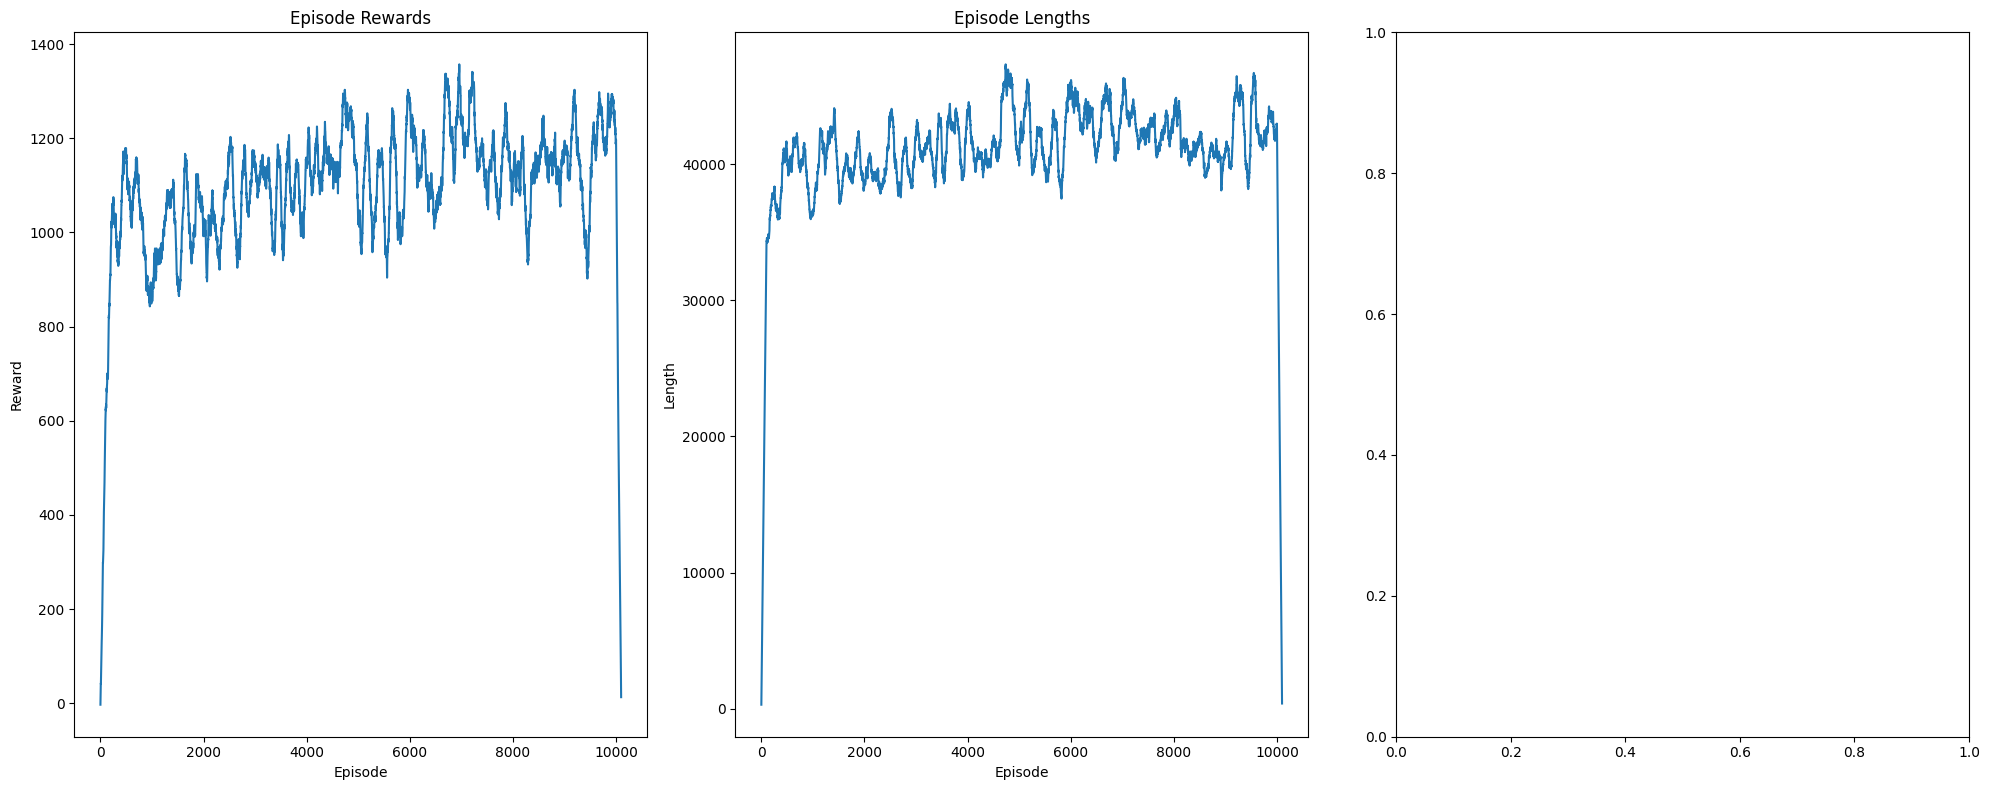

In [21]:
from matplotlib import pyplot as plt
import numpy as np

# visualize the episode rewards, episode length and training error in one figure
fig, axs = plt.subplots(1, 3, figsize=(20, 8))

# np.convolve will compute the rolling mean for 100 episodes

axs[0].plot(np.convolve(env.return_queue, np.ones(100)))
axs[0].set_title("Episode Rewards")
axs[0].set_xlabel("Episode")
axs[0].set_ylabel("Reward")

axs[1].plot(np.convolve(env.length_queue, np.ones(100)))
axs[1].set_title("Episode Lengths")
axs[1].set_xlabel("Episode")
axs[1].set_ylabel("Length")

# axs[2].plot(np.convolve(agent.training_error, np.ones(100)))
# axs[2].set_title("Training Error")
# axs[2].set_xlabel("Episode")
# axs[2].set_ylabel("Temporal Difference")

plt.tight_layout()
plt.show()

# Utilizzo Policy

Di seguito viente utilizzata la policy precedentemente calcolata per registrare degli episodi

In [23]:
num_eval_episodes = 10

env = gym.make("ALE/Qbert-ram-v5", render_mode="rgb_array")
env =  ObsRewardWrapper(env)
env = OurRewardWrapper(env)
env = RecordVideo(env, video_folder="videos_first", name_prefix="eval",
                  episode_trigger=lambda x: True)
env = RecordEpisodeStatistics(env, buffer_length=num_eval_episodes)


for episode_num in range(num_eval_episodes):
    obs, info = env.reset()
    done = False

    while not done:
        action = agent.act(obs, False)
        next_obs, reward, terminated, truncated, info = env.step(action)
        obs =  next_obs

        done = terminated or truncated
env.close()

print(f'Episode time taken: {env.time_queue}')
print(f'Episode total rewards: {env.return_queue}')
print(f'Episode lengths: {env.length_queue}')

print("Training terminato")

/usr/local/lib/python3.11/dist-packages/gymnasium/wrappers/rendering.py:283: UserWarning: WARN: Overwriting existing videos at /content/Q-Bert_RL/videos_first folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(


Episode time taken: deque([0.577941, 0.462291, 0.462108, 0.591425, 0.679309, 0.485817, 0.618417, 0.518381, 0.467278, 0.895119], maxlen=10)
Episode total rewards: deque([9.0, 5.0, 11.0, 14.0, 16.0, 7.0, 18.0, 11.0, 6.0, 13.0], maxlen=10)
Episode lengths: deque([449, 364, 355, 448, 522, 371, 470, 397, 351, 667], maxlen=10)
Training terminato


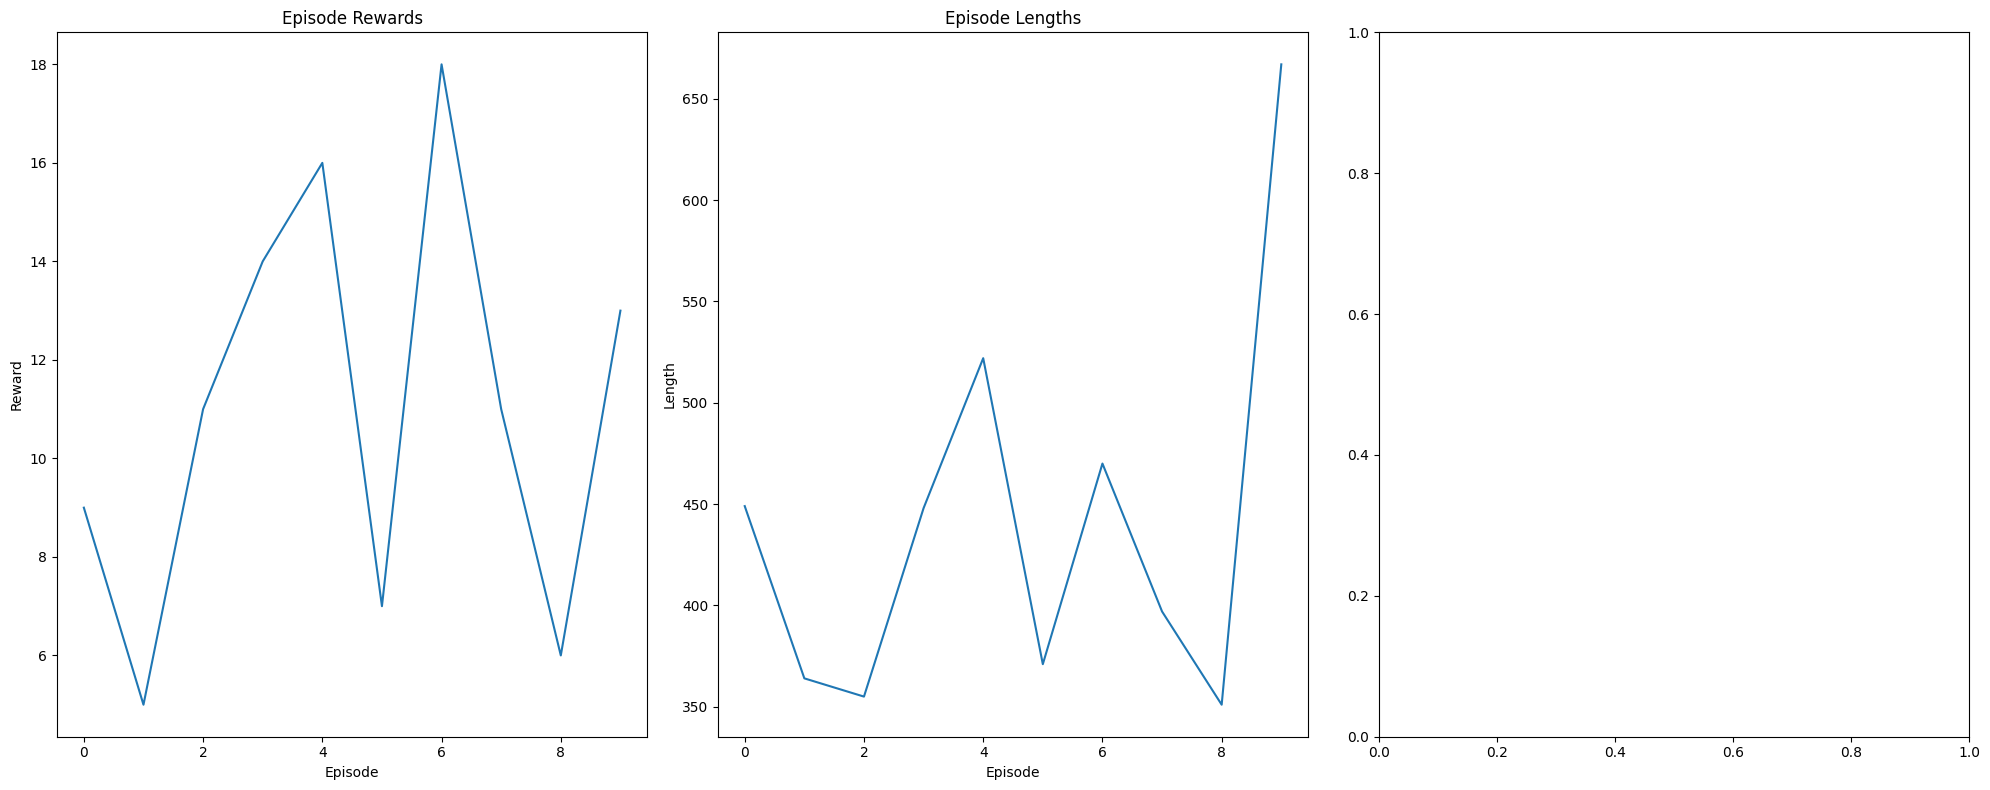

In [24]:
from matplotlib import pyplot as plt
import numpy as np

# visualize the episode rewards, episode length and training error in one figure
fig, axs = plt.subplots(1, 3, figsize=(20, 8))

# np.convolve will compute the rolling mean for 100 episodes

axs[0].plot(env.return_queue)
axs[0].set_title("Episode Rewards")
axs[0].set_xlabel("Episode")
axs[0].set_ylabel("Reward")

axs[1].plot(env.length_queue)
axs[1].set_title("Episode Lengths")
axs[1].set_xlabel("Episode")
axs[1].set_ylabel("Length")

# axs[2].plot(np.convolve(agent.training_error, np.ones(10)))
# axs[2].set_title("Training Error")
# axs[2].set_xlabel("Episode")
# axs[2].set_ylabel("Temporal Difference")

plt.tight_layout()
plt.show()

In [25]:
import shutil

dir_video =  dir + "/video/"
if not os.path.exists(dir_video):
  os.makedirs(dir_video)

source_video = "/content/Q-Bert_RL/videos_first/"

for file_name in os.listdir(source_video):
   source_path = os.path.join(source_video, file_name)
   destination_path = os.path.join(dir_video, file_name)

   if os.path.isfile(source_path):
      shutil.copy2(source_path, destination_path)
      print(f"Copiato: {file_name}")

Copiato: eval-episode-18.mp4
Copiato: eval-episode-3.mp4
Copiato: eval-episode-4.mp4
Copiato: eval-episode-9.mp4
Copiato: eval-episode-1.mp4
Copiato: eval-episode-13.mp4
Copiato: eval-episode-17.mp4
Copiato: eval-episode-0.mp4
Copiato: eval-episode-12.mp4
Copiato: eval-episode-15.mp4
Copiato: eval-episode-5.mp4
Copiato: eval-episode-8.mp4
Copiato: eval-episode-14.mp4
Copiato: eval-episode-2.mp4
Copiato: eval-episode-6.mp4
Copiato: eval-episode-11.mp4
Copiato: eval-episode-20.mp4
Copiato: eval-episode-7.mp4
Copiato: eval-episode-10.mp4
Copiato: eval-episode-16.mp4
Copiato: eval-episode-19.mp4


In [28]:
agent.save(dir_models + "last_model_rew" + str(reward_per_episode[len(reward_per_episode) - 1]) + ".pth" )